In [ ]:
import numpy as np
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
import pandas as pd



Training with Gradient Descent...
Gradient Descent - Test Accuracy: 0.4259

Training with Stochastic GD...
Stochastic GD - Test Accuracy: 0.3385

Training with Mini Batch SGD...
Mini Batch SGD - Test Accuracy: 0.3586

Training with Momentum SGD...
Momentum SGD - Test Accuracy: 0.9161

Training with Nesterov AG...
Nesterov AG - Test Accuracy: 0.9109

Training with AdaGrad...
AdaGrad - Test Accuracy: 0.7889

Training with AdaDelta...
AdaDelta - Test Accuracy: 0.9657

Training with RMSprop...
RMSprop - Test Accuracy: 0.9706

Training with Adam...
Adam - Test Accuracy: 0.9721


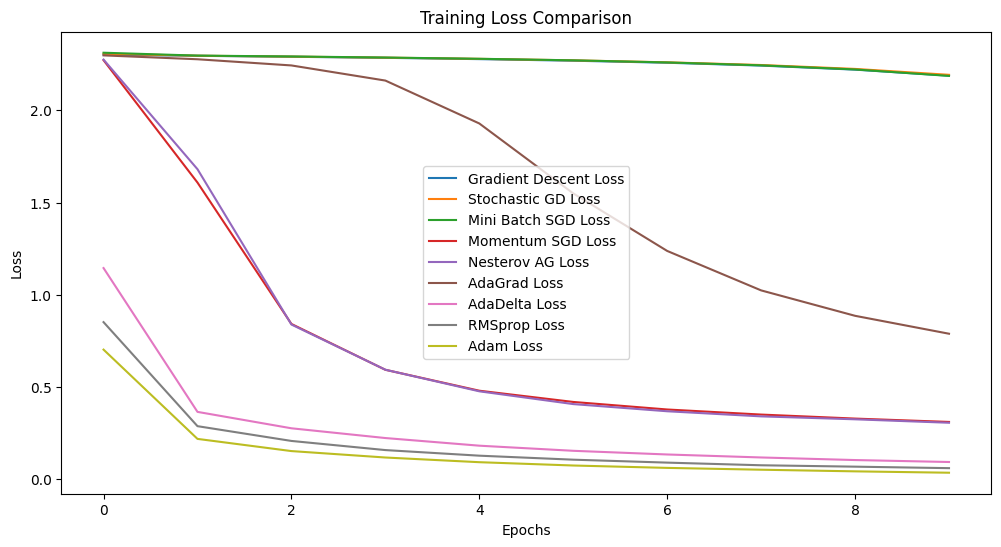

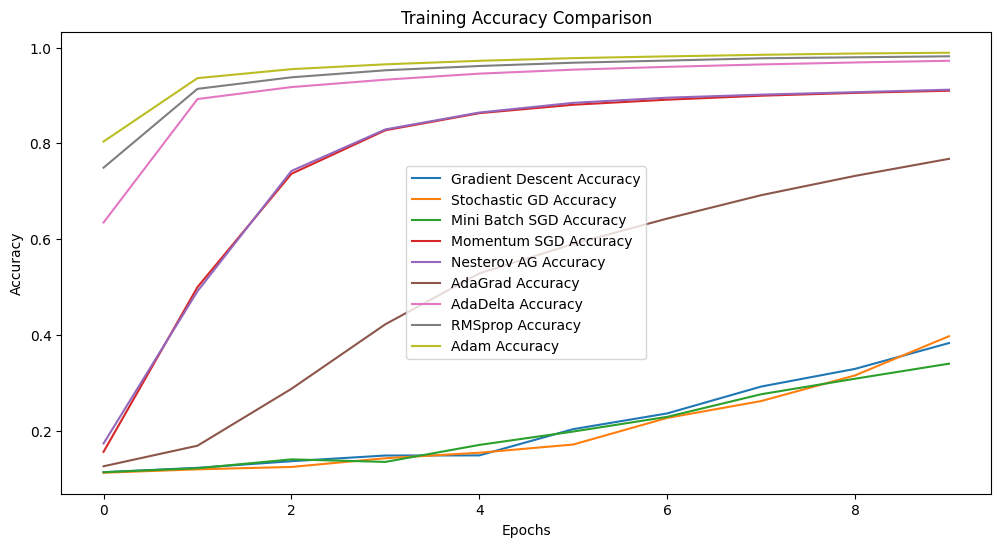


Comparison of Optimizers (Test Accuracy):


,Gradient Descent,Stochastic GD,Mini Batch SGD,Momentum SGD,Nesterov AG,AdaGrad,AdaDelta,RMSprop,Adam
Test Accuracy,0.4259,0.3385,0.3586,0.9161,0.9109,0.7889,0.9657,0.9706,0.9721


In [ ]:
# Load MNIST dataset
mnist_dataset, mnist_info = tfds.load(name='mnist', with_info=True, as_supervised=True)
mnist_train, mnist_test = mnist_dataset['train'], mnist_dataset['test']

# Split validation set (10% of training data)
num_validation_samples = tf.cast(0.1 * mnist_info.splits['train'].num_examples, tf.int64)
num_test_samples = tf.cast(mnist_info.splits['test'].num_examples, tf.int64)

# Normalize images
def scale(image, label):
  return tf.cast(image, tf.float32) / 255., label

# Apply normalization
train_and_validation_data = mnist_train.map(scale).shuffle(10000)
test_data = mnist_test.map(scale).batch(num_test_samples)

# Split validation and training data
validation_data = train_and_validation_data.take(num_validation_samples).batch(num_validation_samples)
train_data = train_and_validation_data.skip(num_validation_samples).batch(100)

# Extract validation inputs and targets
validation_inputs, validation_targets = next(iter(validation_data))

# Define model function to avoid reusing trained weights
def create_model():
  model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28, 1)),
    tf.keras.layers.Dense(256, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),
    tf.keras.layers.Dense(128, activation='sigmoid'),

    tf.keras.layers.Dense(10, activation='softmax')
])
  return model

# List of optimizers to compare
optimizers = {
  "Gradient Descent": tf.keras.optimizers.SGD(learning_rate=0.01),
  "Stochastic GD": tf.keras.optimizers.SGD(learning_rate=0.01, nesterov=False),
  "Mini Batch SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
  "Momentum SGD": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9),
  "Nesterov AG": tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9,
  nesterov=True),
  "AdaGrad": tf.keras.optimizers.Adagrad(learning_rate=0.01),
  "AdaDelta": tf.keras.optimizers.Adadelta(learning_rate=1.0),
  "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
  "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

# Store training history
history_dict = {}

# Train model with different optimizers
for opt_name, opt in optimizers.items():
  print(f"\nTraining with {opt_name}...")
  model = create_model()
  model.compile(optimizer=opt, loss='sparse_categorical_crossentropy',
  metrics=['accuracy'])

  history = model.fit(train_data, epochs=10, validation_data=(validation_inputs,
  validation_targets), verbose=0)

  test_loss, test_acc = model.evaluate(test_data, verbose=0)

  history_dict[opt_name] = {
  "train_loss": history.history['loss'],
  "val_loss": history.history['val_loss'],
  "train_acc": history.history['accuracy'],
  "val_acc": history.history['val_accuracy'],
  "test_acc": test_acc
  }
  print(f"{opt_name} - Test Accuracy: {test_acc:.4f}")

# Plot Training Curves
plt.figure(figsize=(12, 6))
for opt_name, hist in history_dict.items():
  plt.plot(hist["train_loss"], label=f"{opt_name} Loss")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
for opt_name, hist in history_dict.items():
  plt.plot(hist["train_acc"], label=f"{opt_name} Accuracy")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Create table for test accuracy
results_df = pd.DataFrame({opt: [hist["test_acc"]] for opt, hist in history_dict.items()},
index=["Test Accuracy"])
print("\nComparison of Optimizers (Test Accuracy):")
results_df